In [236]:
import pandas as pd
import numpy as np
data = pd.read_excel('/content/Strikers_performance.xlsx')
data.head()

,Striker_ID,Nationality,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct
0,1,Spain,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,71.806409,15.682532,30.412215,6.152481,0.820314,0.922727,8.570370,11.451388
1,2,France,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,53.726866,19.843983,26.474913,6.093172,0.803321,0.678984,3.444638,8.243689
2,3,Germany,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,60.452227,20.090084,24.164116,3.408714,0.766540,0.843858,8.429491,9.506835
3,4,France,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,60.511979,22.363152,44.129989,6.339820,0.611798,0.662997,6.532552,8.199653
4,5,France,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,54.982158,13.165708,37.859323,8.465658,0.701638,0.906538,8.414915,6.665333


# **FINDING MISSING VALUES**

In [26]:
missing_values = data.isnull().sum()
missing_values

,0
Striker_ID,0
Nationality,0
Footedness,0
Marital Status,0
Goals Scored,0
Assists,0
Shots on Target,0
Shot Accuracy,0
Conversion Rate,0
Dribbling Success,0


# **DEALING WITH MISSING VALUES**

In [27]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputer.fit(data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']])
data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']]=imputer.transform(data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']])

In [28]:
data.dtypes
missing_values = data.isnull().sum()
missing_values

,0
Striker_ID,0
Nationality,0
Footedness,0
Marital Status,0
Goals Scored,0
Assists,0
Shots on Target,0
Shot Accuracy,0
Conversion Rate,0
Dribbling Success,0


# **ASSIGNING DATATYPE**

In [29]:
data[['Goals Scored', 'Assists', 'Shots on Target', 'Movement off the Ball', 'Hold-up Play', 'Aerial Duels Won', 'Defensive Contribution', 'Big Game Performance', 'Impact on Team Performance', 'Off-field Conduct']]=data[['Goals Scored', 'Assists', 'Shots on Target', 'Movement off the Ball', 'Hold-up Play', 'Aerial Duels Won', 'Defensive Contribution', 'Big Game Performance', 'Impact on Team Performance', 'Off-field Conduct']].astype(int)
data.dtypes

,0
Striker_ID,int64
Nationality,object
Footedness,object
Marital Status,object
Goals Scored,int64
Assists,int64
Shots on Target,int64
Shot Accuracy,float64
Conversion Rate,float64
Dribbling Success,float64


# **Descriptive Analysis**

In [175]:
round(data.describe(),2)

,Striker_ID,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct,Total contribution score,Footedness_encoded,Marital_Status_encoded
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00,494.00,500.00,500.00,500.00,498.00,500.00,495.00,500.00,500.00,498.00,500.00,500.00
mean,250.50,15.04,8.10,25.76,0.60,0.20,0.70,69.79,59.81,19.53,39.95,6.93,0.74,0.80,7.01,8.06,116.74,0.53,0.52
std,144.48,4.90,2.93,7.07,0.10,0.05,0.10,10.40,10.17,4.96,9.92,1.94,0.10,0.10,2.10,2.07,14.13,0.50,0.50
min,1.00,0.00,0.00,4.73,0.31,0.05,0.40,40.71,35.07,4.96,8.23,2.23,0.46,0.53,0.56,0.62,69.82,0.00,0.00
25%,125.75,11.50,6.21,20.78,0.54,0.17,0.64,62.67,52.43,16.40,33.46,5.68,0.68,0.72,5.66,6.62,107.85,0.00,0.00
50%,250.50,15.06,8.09,25.84,0.60,0.20,0.70,69.62,60.08,19.74,39.98,6.91,0.75,0.80,6.99,8.02,116.99,1.00,1.00
75%,375.25,18.18,9.95,30.28,0.67,0.23,0.76,76.95,66.03,22.86,46.69,8.18,0.81,0.87,8.43,9.45,125.35,1.00,1.00
max,500.00,34.26,15.90,43.21,0.92,0.36,1.00,98.68,92.43,34.07,71.13,12.87,1.00,1.00,13.24,13.73,160.84,1.00,1.00


# **DATA VISUALIZATION**

In [237]:
import matplotlib.pyplot as plt
import seaborn as sns

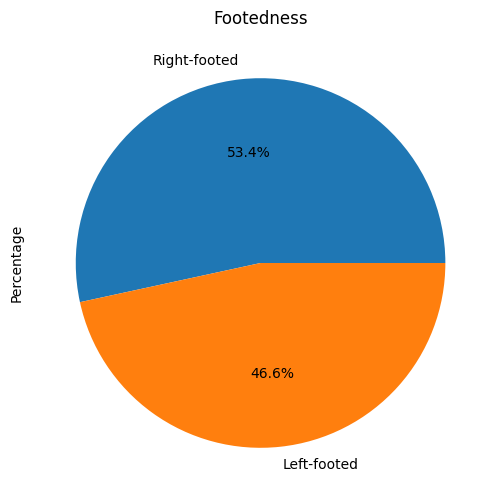

In [174]:
frequency = data['Footedness'].value_counts()
percentage=frequency/len(data['Footedness'])*100
plt.figure(figsize=(10,6))
percentage.plot(kind='pie',autopct='%1.1f%%')
plt.title('Footedness')
plt.ylabel('Percentage')
plt.show()

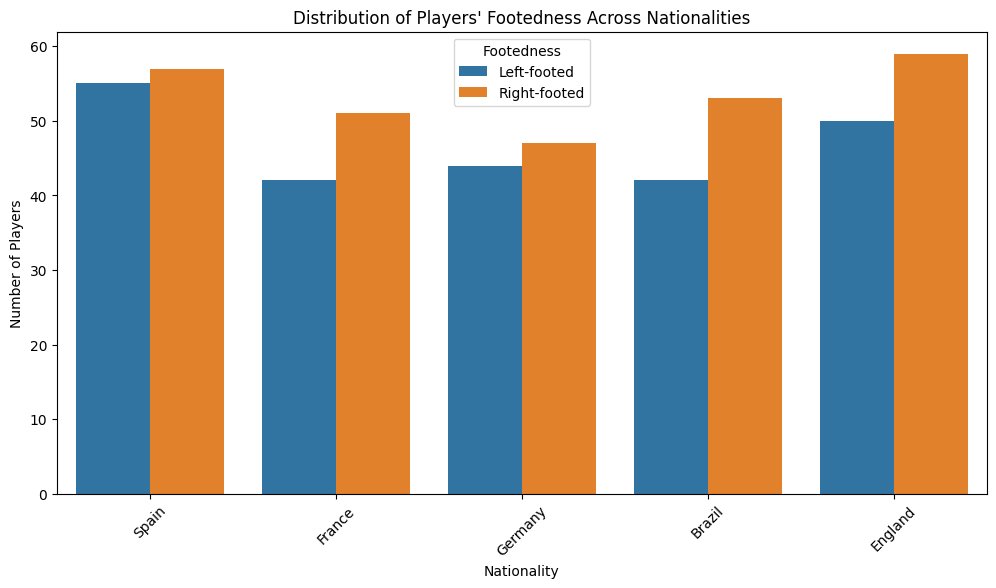

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    x='Nationality',
    hue='Footedness',
    data=data
)

plt.title("Distribution of Players' Footedness Across Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Number of Players")
plt.xticks(rotation=45)
plt.show()


In [242]:
footedness_by_nationality = pd.crosstab(data['Nationality'], data['Footedness'])
footedness_by_nationality

Footedness,Left-footed,Right-footed
Nationality,,
Brazil,42,53
England,50,59
France,42,51
Germany,44,47
Spain,55,57


# **Statistical Analysis**

In [ ]:
'''1️⃣ Determine which nationality strikers have the highest average number of goals scored.'''
grouped_data = data.groupby('Nationality')['Goals Scored'].mean()
grouped_data

,Goals Scored
Nationality,
Brazil,15.315789
England,13.899083
France,14.408602
Germany,14.351648
Spain,14.687500


In [ ]:
'''2️⃣ Calculate the average conversion rate for players based on their footedness.'''
grouped_cr = data.groupby('Footedness')['Conversion Rate'].mean()
grouped_cr


,Conversion Rate
Footedness,
Left-footed,0.198086
Right-footed,0.200592


Text(0, 0.5, 'Consistency Rate')

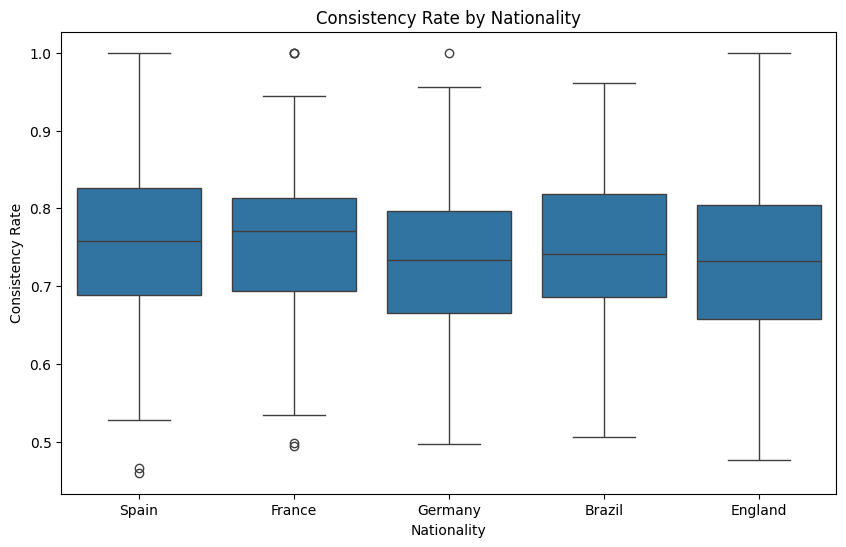

In [ ]:
'''3️⃣ Find whether there is any significant difference in consistency rates among strikers from various nationalities. Must check assumptions.'''
plt.figure(figsize=(10,6))
sns.boxplot(x='Nationality',y='Consistency', data=data)
plt.title('Consistency Rate by Nationality')
plt.xlabel('Nationality')
plt.ylabel('Consistency Rate')


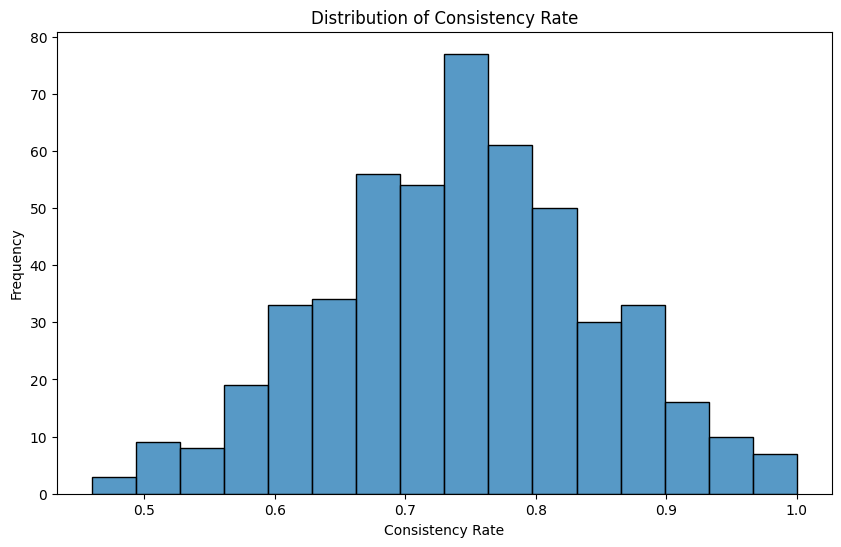

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(data['Consistency'])
plt.title('Distribution of Consistency Rate')
plt.xlabel('Consistency Rate')
plt.ylabel('Frequency')
plt.show()

In [180]:
from scipy.stats import shapiro
shapiro_results={}
for column in data.columns:
  Stat,p_value = shapiro(data['Consistency'])
  shapiro_results['Consistency']={'Stat':Stat,'p_value':p_value}
shapiro_results

{'Consistency': {'Stat': np.float64(0.9968719443391263),
  'p_value': np.float64(0.45127699414580213)}}

In [176]:
from scipy import stats
from scipy.stats import levene
Brazil = data.query('Nationality == "Brazil"')['Consistency']
England = data.query('Nationality == "England"')['Consistency']
France = data.query('Nationality == "France"')['Consistency']
Germany = data.query('Nationality == "Germany"')['Consistency']
Spain = data.query('Nationality == "Spain"')['Consistency']
t_stat,p_value = stats.f_oneway(Brazil,England,France,Germany,Spain)
print('t-statistic:',t_stat)
print('p-value:',p_value)


t-statistic: 1.5278984293635938
p-value: 0.19278675901599154


In [177]:
Stats,p_value = levene(Brazil,England,France,Germany,Spain)
print('Stats:',Stats)
print('p-value:',p_value)

Stats: 0.40038650984072066
p-value: 0.8083990350934653


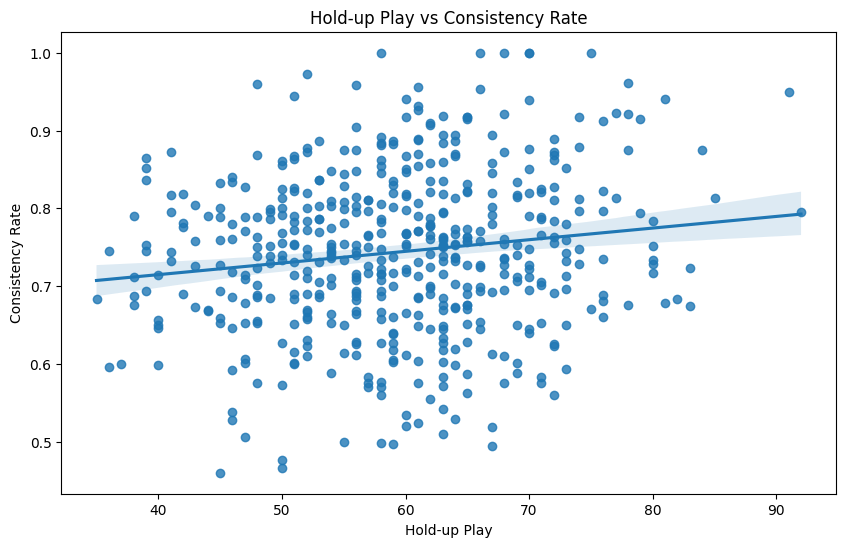

In [ ]:
'''4️⃣ Check if there is any significant correlation between hold-up play and consistency rate. Must check assumptions.'''
plt.figure(figsize=(10,6))
sns.regplot(x='Hold-up Play',y='Consistency', data=data)
plt.title('Hold-up Play vs Consistency Rate')
plt.xlabel('Hold-up Play')
plt.ylabel('Consistency Rate')
plt.show()

In [ ]:
from scipy.stats import pearsonr
correlation, p_value = pearsonr(data['Hold-up Play'], data['Consistency'])
print("Correlation coefficient:", correlation)
print("p-value:", p_value)

Correlation coefficient: 0.14654573283554145
p-value: 0.0010146963053630602


In [ ]:
'''5️⃣ Check if hold-up play significantly influences consistency rate.'''
import statsmodels.api as sm
x =data['Hold-up Play']
y =data['Consistency']
x_and_constant = sm.add_constant(x)
model = sm.OLS(y,x_and_constant).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            Consistency   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     10.93
Date:                Fri, 26 Dec 2025   Prob (F-statistic):            0.00101
Time:                        09:12:51   Log-Likelihood:                 429.97
No. Observations:                 500   AIC:                            -855.9
Df Residuals:                     498   BIC:                            -847.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.6548      0.027     24.031      0.000       0.601       0.708
Hold-up Play     0.0015      0.000      3.306      0.001       0.001       0.002
==============================================================================
Omnibus:                        1.708   Durbin-Watson:                   2.135
Prob(Omnibus):                  0.426   Jarque-Bera (JB):                1.744
Skew:                          -0.100   Prob(JB):                        0.418
Kurtosis:                       2.791   Cond. No.                         358.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# **Feature Engineering**

In [299]:
data = pd.read_excel('/content/Strikers_performance.xlsx')
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
imputer.fit(data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']])
data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']]=imputer.transform(data[['Movement off the Ball','Big Game Performance','Penalty Success Rate']])

In [300]:
data['Total contribution score']=data['Goals Scored']+ data['Assists']+ data['Shots on Target']+ data['Dribbling Success']+ data['Aerial Duels Won']+data['Defensive Contribution']+data['Big Game Performance'] +data['Consistency']
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
data['Footedness_encoded'] = encoder.fit_transform(data['Footedness'])
data['Marital_Status_encoded'] = encoder.fit_transform(data['Marital Status'])

In [301]:
data.columns
data.head()


,Striker_ID,Nationality,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,...,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct,Total contribution score,Footedness_encoded,Marital_Status_encoded
0,1,Spain,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,...,15.682532,30.412215,6.152481,0.820314,0.922727,8.570370,11.451388,116.882195,0,0
1,2,France,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,...,19.843983,26.474913,6.093172,0.803321,0.678984,3.444638,8.243689,113.521571,0,1
2,3,Germany,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,...,20.090084,24.164116,3.408714,0.766540,0.843858,8.429491,9.506835,96.556476,0,0
3,4,France,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,...,22.363152,44.129989,6.339820,0.611798,0.662997,6.532552,8.199653,126.859035,1,0
4,5,France,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,...,13.165708,37.859323,8.465658,0.701638,0.906538,8.414915,6.665333,110.548681,0,1


In [302]:
dummies = pd.get_dummies(data['Nationality'])
data = pd.concat([data, dummies], axis = 1)
data = data.drop('Nationality', axis = 1)
data.head()

,Striker_ID,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,...,Impact on Team Performance,Off-field Conduct,Total contribution score,Footedness_encoded,Marital_Status_encoded,Brazil,England,France,Germany,Spain
0,1,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,...,8.570370,11.451388,116.882195,0,0,False,False,False,False,True
1,2,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,...,3.444638,8.243689,113.521571,0,1,False,False,True,False,False
2,3,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,...,8.429491,9.506835,96.556476,0,0,False,False,False,True,False
3,4,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,...,6.532552,8.199653,126.859035,1,0,False,False,True,False,False
4,5,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,...,8.414915,6.665333,110.548681,0,1,False,False,True,False,False


# **Clustering Analysis**

In [303]:
from sklearn.cluster import KMeans

data.columns

Index(['Striker_ID', 'Footedness', 'Marital Status', 'Goals Scored', 'Assists',
       'Shots on Target', 'Shot Accuracy', 'Conversion Rate',
       'Dribbling Success', 'Movement off the Ball', 'Hold-up Play',
       'Aerial Duels Won', 'Defensive Contribution', 'Big Game Performance',
       'Consistency', 'Penalty Success Rate', 'Impact on Team Performance',
       'Off-field Conduct', 'Total contribution score', 'Footedness_encoded',
       'Marital_Status_encoded', 'Brazil', 'England', 'France', 'Germany',
       'Spain'],
      dtype='object')

In [304]:
x=data.drop(columns=['Striker_ID'],axis =1)
x.columns

Index(['Footedness', 'Marital Status', 'Goals Scored', 'Assists',
       'Shots on Target', 'Shot Accuracy', 'Conversion Rate',
       'Dribbling Success', 'Movement off the Ball', 'Hold-up Play',
       'Aerial Duels Won', 'Defensive Contribution', 'Big Game Performance',
       'Consistency', 'Penalty Success Rate', 'Impact on Team Performance',
       'Off-field Conduct', 'Total contribution score', 'Footedness_encoded',
       'Marital_Status_encoded', 'Brazil', 'England', 'France', 'Germany',
       'Spain'],
      dtype='object')

In [305]:
x_numeric = x.select_dtypes(include=['int64', 'float64'])

In [306]:
wcss = []

for i in range(1, 15):
    kmeans = KMeans(n_clusters = i, init = 'k-means++')
    kmeans.fit(x_numeric)
    wcss_score = kmeans.inertia_
    wcss.append(wcss_score)

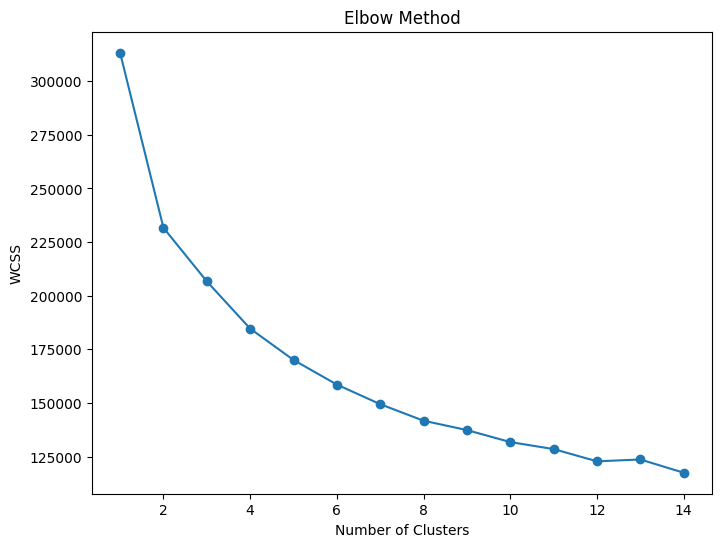

In [307]:
plt.figure(figsize=(8,6))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [308]:
kmeans = KMeans(n_clusters=2)
kmeans.fit(x_numeric)
labels = kmeans.labels_
labels

array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0,

In [315]:
data.head()

,Striker_ID,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,...,Impact on Team Performance,Off-field Conduct,Total contribution score,Footedness_encoded,Marital_Status_encoded,Brazil,England,France,Germany,Spain
0,1,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,...,8.570370,11.451388,116.882195,0,0,False,False,False,False,True
1,2,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,...,3.444638,8.243689,113.521571,0,1,False,False,True,False,False
2,3,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,...,8.429491,9.506835,96.556476,0,0,False,False,False,True,False
3,4,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,...,6.532552,8.199653,126.859035,1,0,False,False,True,False,False
4,5,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,...,8.414915,6.665333,110.548681,0,1,False,False,True,False,False


In [316]:
data['Clusters'] = labels
data.head()
Avg_TCS = data.groupby('Clusters')['Total contribution score'].mean()
Avg_TCS


,Total contribution score
Clusters,
0,104.959095
1,126.555178


In [317]:
mapping = {1:'Regular Strikers',0:'Best Strikers'}
data['Strikers types'] = data['Clusters'].map(mapping)
data.head()


,Striker_ID,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,...,Total contribution score,Footedness_encoded,Marital_Status_encoded,Brazil,England,France,Germany,Spain,Clusters,Strikers types
0,1,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,...,116.882195,0,0,False,False,False,False,True,0,Best Strikers
1,2,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,...,113.521571,0,1,False,False,True,False,False,0,Best Strikers
2,3,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,...,96.556476,0,0,False,False,False,True,False,0,Best Strikers
3,4,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,...,126.859035,1,0,False,False,True,False,False,1,Regular Strikers
4,5,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,...,110.548681,0,1,False,False,True,False,False,0,Best Strikers


In [318]:
data1=data.drop(columns=['Clusters'],axis =1)
data1.head()

,Striker_ID,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,...,Off-field Conduct,Total contribution score,Footedness_encoded,Marital_Status_encoded,Brazil,England,France,Germany,Spain,Strikers types
0,1,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,...,11.451388,116.882195,0,0,False,False,False,False,True,Best Strikers
1,2,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,...,8.243689,113.521571,0,1,False,False,True,False,False,Best Strikers
2,3,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,...,9.506835,96.556476,0,0,False,False,False,True,False,Best Strikers
3,4,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,...,8.199653,126.859035,1,0,False,False,True,False,False,Regular Strikers
4,5,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,...,6.665333,110.548681,0,1,False,False,True,False,False,Best Strikers


In [319]:
mapping_strikers = {'Regular Strikers':0,'Best Strikers':1}
data1['New_Striker_Types'] = data1['Strikers types'].map(mapping_strikers)
data1.head()

,Striker_ID,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,...,Total contribution score,Footedness_encoded,Marital_Status_encoded,Brazil,England,France,Germany,Spain,Strikers types,New_Striker_Types
0,1,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,...,116.882195,0,0,False,False,False,False,True,Best Strikers,1
1,2,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,...,113.521571,0,1,False,False,True,False,False,Best Strikers,1
2,3,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,...,96.556476,0,0,False,False,False,True,False,Best Strikers,1
3,4,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,...,126.859035,1,0,False,False,True,False,False,Regular Strikers,0
4,5,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,...,110.548681,0,1,False,False,True,False,False,Best Strikers,1


# **Machine Learning Model**

In [320]:
x = data1.drop(['Strikers types'],axis=1)
x_numeric = x.select_dtypes(include=['int64', 'float64'])
y = data1['Strikers types']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_numeric)

In [321]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


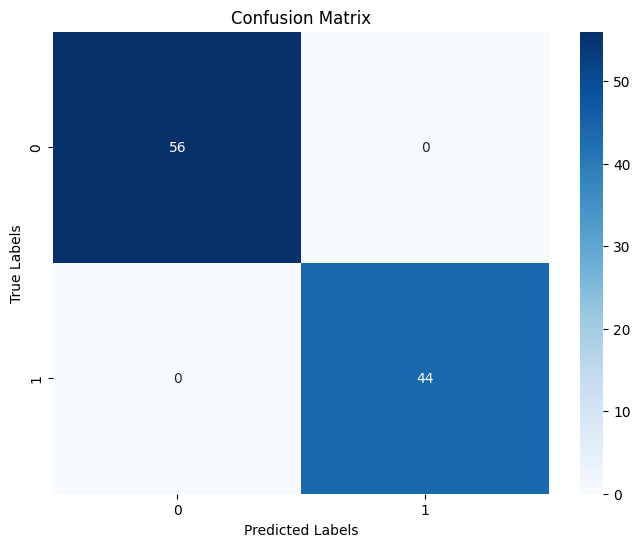

In [241]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()